# Notebook 05 — Cohort & Retention Analysis

## Brazilian E-Commerce Public Dataset by Olist

### Objetivo

Analisar a evolução das **coortes de aquisição** do e-commerce Olist, medindo:

- retenção mensal;
- recompra acumulada;
- receita por safra;
- receita acumulada por cliente adquirido;
- diferenças associadas ao meio principal de pagamento da primeira compra.

Este notebook complementa o Notebook 04:

- o Notebook 04 responde **se o cliente recomprou dentro de uma janela fixa**;
- o Notebook 05 responde **como cada safra de aquisição evolui ao longo dos meses**.

### Perguntas de negócio

- Quantos clientes são adquiridos em cada mês?
- Qual percentual volta em M1, M2, M3, M6 e M12?
- A retenção melhorou ou piorou entre safras?
- Quanto da receita inicial de uma coorte reaparece nos meses seguintes?
- Qual o valor acumulado por cliente adquirido ao longo do tempo?
- O meio principal de pagamento da primeira compra está associado a padrões distintos de retenção?
- Quais coortes performam acima ou abaixo do benchmark?

> **Importante:** em e-commerce transacional, retenção mensal tende a ser baixa. Por isso, este notebook separa claramente **retenção mensal exata**, **recompra acumulada** e **valor acumulado**.


## 1. Configuração e carregamento

Este notebook depende explicitamente de:

- `orders_base.csv`, produzido no Notebook 01;
- `payment_behavior_order_level.csv`, produzido no Notebook 02.

Não há reconstrução alternativa das bases. Essa decisão mantém a arquitetura do projeto simples, rastreável e reproduzível.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

orders_base_path = PROCESSED_DIR / "orders_base.csv"
payment_behavior_path = (
    PROCESSED_DIR / "payment_behavior_order_level.csv"
)

if not orders_base_path.exists():
    raise FileNotFoundError(
        "orders_base.csv não encontrado. "
        "Execute primeiro o Notebook 01."
    )

if not payment_behavior_path.exists():
    raise FileNotFoundError(
        "payment_behavior_order_level.csv não encontrado. "
        "Execute primeiro o Notebook 02 revisado."
    )

orders_base = pd.read_csv(
    orders_base_path,
    parse_dates=["order_purchase_timestamp"]
)

payment_behavior = pd.read_csv(
    payment_behavior_path
)

print("orders_base:", orders_base.shape)
print("payment_behavior:", payment_behavior.shape)


orders_base: (99441, 16)
payment_behavior: (99440, 7)


## 2. Universo analítico e maturidade temporal

In [2]:
required_cols = {
    "order_id",
    "customer_unique_id",
    "order_status",
    "order_purchase_timestamp",
    "payment_value",
}

missing = required_cols.difference(
    orders_base.columns
)

if missing:
    raise ValueError(
        f"Colunas obrigatórias ausentes em orders_base: {sorted(missing)}"
    )

delivered = (
    orders_base.loc[
        orders_base["order_status"].eq("delivered")
        & orders_base["customer_unique_id"].notna()
        & orders_base["order_purchase_timestamp"].notna()
    ]
    .copy()
)

delivered["payment_value"] = pd.to_numeric(
    delivered["payment_value"],
    errors="coerce",
)

delivered = (
    delivered
    .sort_values(
        [
            "customer_unique_id",
            "order_purchase_timestamp",
            "order_id",
        ]
    )
    .reset_index(drop=True)
)

delivered["order_month"] = (
    delivered["order_purchase_timestamp"]
    .dt.to_period("M")
)

dataset_start = (
    delivered["order_purchase_timestamp"].min()
)

dataset_end = (
    delivered["order_purchase_timestamp"].max()
)

last_observed_month = (
    dataset_end.to_period("M")
)

month_end = (
    dataset_end
    + pd.offsets.MonthEnd(0)
)

if dataset_end.normalize() < month_end.normalize():
    last_complete_month = (
        last_observed_month - 1
    )
else:
    last_complete_month = (
        last_observed_month
    )

print("Período entregue:", dataset_start, "→", dataset_end)
print("Último mês observado:", last_observed_month)
print("Último mês completo:", last_complete_month)
print("Pedidos entregues:", f"{len(delivered):,}")
print(
    "Clientes únicos:",
    f"{delivered['customer_unique_id'].nunique():,}"
)


Período entregue: 2016-09-15 12:16:38 → 2018-08-29 15:00:37
Último mês observado: 2018-08
Último mês completo: 2018-07
Pedidos entregues: 96,478
Clientes únicos: 93,358


### Governança financeira

A retenção de clientes usa todos os pedidos entregues válidos.

As análises financeiras utilizam somente pedidos com `payment_value`:

- não nulo;
- maior ou igual a zero.

Ausência de `payment_value` não é interpretada como receita zero.


In [3]:
payment_quality = pd.Series({
    "delivered_orders":
        len(delivered),
    "missing_payment_value":
        int(
            delivered[
                "payment_value"
            ].isna().sum()
        ),
    "negative_payment_value":
        int(
            delivered[
                "payment_value"
            ].lt(0).sum()
        ),
})

payment_quality


delivered_orders          96478
missing_payment_value         1
negative_payment_value        0
dtype: int64

In [4]:
delivered_financial = (
    delivered.loc[
        delivered["payment_value"].notna()
        & delivered["payment_value"].ge(0)
    ]
    .copy()
)

print(
    "Pedidos válidos para análises financeiras:",
    f"{len(delivered_financial):,}"
)


Pedidos válidos para análises financeiras: 96,477


## 3. Definição das coortes

A coorte de cada cliente é o **mês da primeira compra entregue**.

O `cohort_index` mede quantos meses se passaram desde a aquisição:

- `M0`: mês da primeira compra;
- `M1`: mês seguinte;
- `M2`: dois meses depois;
- etc.


In [5]:
first_purchase_month = (
    delivered
    .groupby(
        "customer_unique_id"
    )["order_month"]
    .min()
    .rename("cohort_month")
)

delivered = (
    delivered
    .merge(
        first_purchase_month,
        on="customer_unique_id",
        how="left",
        validate="many_to_one",
    )
)

delivered_financial = (
    delivered_financial
    .merge(
        first_purchase_month,
        on="customer_unique_id",
        how="left",
        validate="many_to_one",
    )
)

def month_diff(month_a, month_b):
    return (
        (month_a.dt.year - month_b.dt.year) * 12
        + (month_a.dt.month - month_b.dt.month)
    )

delivered["cohort_index"] = (
    month_diff(
        delivered["order_month"],
        delivered["cohort_month"],
    )
    .astype(int)
)

delivered_financial["cohort_index"] = (
    month_diff(
        delivered_financial["order_month"],
        delivered_financial["cohort_month"],
    )
    .astype(int)
)

assert delivered["cohort_index"].ge(0).all()

display(
    delivered[
        [
            "customer_unique_id",
            "order_id",
            "order_month",
            "cohort_month",
            "cohort_index",
        ]
    ].head()
)


,customer_unique_id,order_id,order_month,cohort_month,cohort_index
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05,2018-05,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05,2018-05,0
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03,2017-03,0
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10,2017-10,0
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11,2017-11,0


## 4. Aquisição por coorte

,cohort_month,acquired_customers,cohort_month_str
0,2016-09,1,2016-09
1,2016-10,262,2016-10
2,2016-12,1,2016-12
3,2017-01,717,2017-01
4,2017-02,1628,2017-02
5,2017-03,2503,2017-03
6,2017-04,2256,2017-04
7,2017-05,3451,2017-05
8,2017-06,3037,2017-06
9,2017-07,3752,2017-07


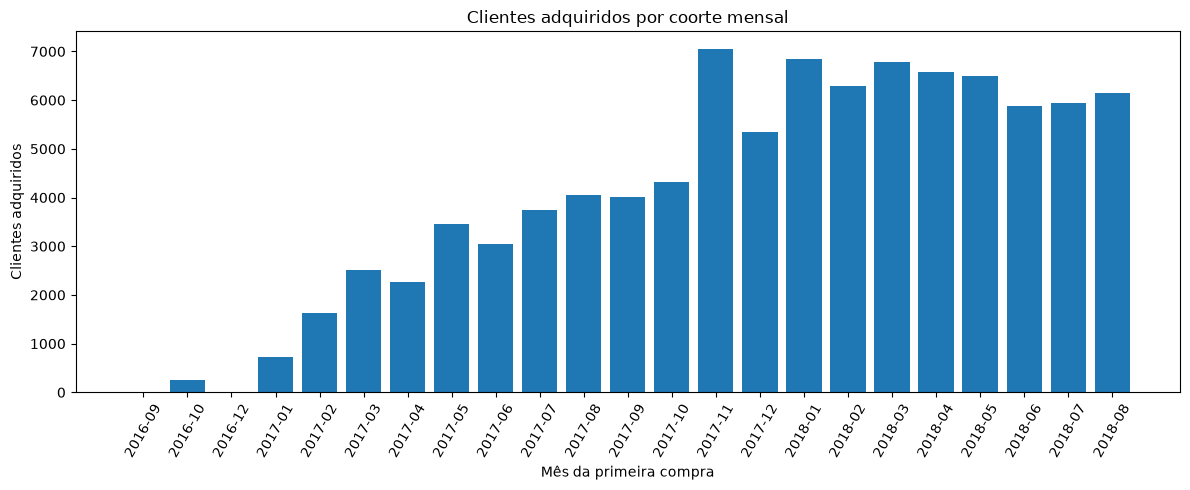

In [6]:
cohort_sizes = (
    first_purchase_month
    .reset_index()
    .groupby(
        "cohort_month"
    )
    .agg(
        acquired_customers=(
            "customer_unique_id",
            "nunique",
        )
    )
    .reset_index()
    .sort_values(
        "cohort_month"
    )
)

cohort_sizes["cohort_month_str"] = (
    cohort_sizes["cohort_month"].astype(str)
)

display(cohort_sizes)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    cohort_sizes["cohort_month_str"],
    cohort_sizes["acquired_customers"],
)

ax.set_title(
    "Clientes adquiridos por coorte mensal"
)
ax.set_xlabel(
    "Mês da primeira compra"
)
ax.set_ylabel(
    "Clientes adquiridos"
)

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


## 5. Matriz de retenção mensal de clientes

A retenção em `Mk` é a proporção de clientes da coorte que fizeram **pelo menos uma compra naquele mês específico**.

Para tornar o cálculo robusto:

- o tamanho da coorte vem da população oficial de aquisição (`cohort_sizes`);
- o numerador conta clientes únicos ativos em cada `cohort_month × cohort_index`;
- antes da divisão, é validado que o número de clientes ativos nunca supera o tamanho da coorte;
- coortes adquiridas em mês calendário incompleto não entram na matriz comparativa;
- meses já observáveis sem atividade recebem `0`;
- meses futuros ou ainda não observáveis permanecem como `NaN`.

Os `NaN` da matriz são, portanto, **intencionais** e representam ausência de janela de observação, não erro ou retenção zero.

A maturidade é calculada usando o **último mês calendário completo**, não o último mês parcialmente observado.


In [7]:
# População elegível para a matriz comparativa:
# apenas coortes cuja aquisição ocorreu até o último mês calendário completo.
cohort_sizes_retention = (
    cohort_sizes.loc[
        cohort_sizes["cohort_month"].le(last_complete_month),
        [
            "cohort_month",
            "acquired_customers",
        ],
    ]
    .copy()
)

# Uma única ocorrência por cliente em cada mês relativo da coorte.
customer_month_activity = (
    delivered.loc[
        delivered["cohort_month"].le(last_complete_month),
        [
            "customer_unique_id",
            "cohort_month",
            "cohort_index",
        ],
    ]
    .drop_duplicates(
        subset=[
            "customer_unique_id",
            "cohort_month",
            "cohort_index",
        ]
    )
)

cohort_activity_long = (
    customer_month_activity
    .groupby(
        [
            "cohort_month",
            "cohort_index",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        active_customers=(
            "customer_unique_id",
            "nunique",
        )
    )
    .merge(
        cohort_sizes_retention,
        on="cohort_month",
        how="left",
        validate="many_to_one",
    )
)

# Diagnóstico estrutural: um mês da coorte nunca pode ter
# mais clientes ativos do que a população adquirida.
invalid_activity = (
    cohort_activity_long.loc[
        cohort_activity_long["active_customers"]
        > cohort_activity_long["acquired_customers"]
    ]
)

if not invalid_activity.empty:
    display(invalid_activity)

    raise ValueError(
        "Há contagem de clientes ativos superior ao tamanho da coorte. "
        "Revise a definição de cohort_month/cohort_index."
    )

cohort_activity_long["retention_rate"] = (
    cohort_activity_long["active_customers"]
    / cohort_activity_long["acquired_customers"]
)

# M0 precisa representar toda a população adquirida da coorte.
m0_check = (
    cohort_activity_long.loc[
        cohort_activity_long["cohort_index"].eq(0),
        [
            "cohort_month",
            "active_customers",
            "acquired_customers",
        ],
    ]
    .copy()
)

if not (
    m0_check["active_customers"]
    .eq(m0_check["acquired_customers"])
    .all()
):
    display(
        m0_check.loc[
            m0_check["active_customers"]
            .ne(m0_check["acquired_customers"])
        ]
    )

    raise ValueError(
        "M0 não coincide com o tamanho oficial de alguma coorte."
    )

max_age = int(
    max(
        (
            last_complete_month.year - cm.year
        ) * 12
        + (
            last_complete_month.month - cm.month
        )
        for cm in cohort_sizes_retention["cohort_month"]
    )
)

customer_retention = (
    cohort_activity_long
    .pivot(
        index="cohort_month",
        columns="cohort_index",
        values="retention_rate",
    )
    .reindex(
        index=cohort_sizes_retention["cohort_month"],
        columns=range(max_age + 1),
    )
    .sort_index()
)

# Zeros significam "mês já observável, mas sem cliente ativo".
# Meses futuros permanecem NaN.
for cm in customer_retention.index:
    observed_age = (
        (last_complete_month.year - cm.year) * 12
        + (last_complete_month.month - cm.month)
    )

    observed_cols = (
        customer_retention.columns <= observed_age
    )

    customer_retention.loc[
        cm,
        observed_cols
    ] = (
        customer_retention.loc[
            cm,
            observed_cols
        ]
        .fillna(0.0)
    )

    customer_retention.loc[
        cm,
        customer_retention.columns > observed_age
    ] = np.nan

customer_retention.index = (
    customer_retention.index.astype(str)
)

customer_retention.index.name = (
    "cohort_month"
)

customer_retention.columns = [
    f"M{i}"
    for i in customer_retention.columns
]

display(
    (
        customer_retention.iloc[:, :13]
        * 100
    ).round(2)
)


,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
cohort_month,,,,,,,,,,,,,
2016-09,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2016-10,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3800,0.0000,0.0000,0.3800,0.0000,0.3800,0.0000
2016-12,100.0000,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2017-01,100.0000,0.2800,0.2800,0.1400,0.4200,0.1400,0.4200,0.1400,0.1400,0.0000,0.4200,0.1400,0.7000
2017-02,100.0000,0.1800,0.3100,0.1200,0.4300,0.1200,0.2500,0.1800,0.1200,0.1800,0.1200,0.3100,0.1200
2017-03,100.0000,0.4400,0.3600,0.4000,0.3600,0.1600,0.1600,0.3200,0.3200,0.0800,0.3600,0.1200,0.2000
2017-04,100.0000,0.6200,0.2200,0.1800,0.2700,0.2700,0.3500,0.3100,0.3100,0.1800,0.2700,0.0900,0.0400
2017-05,100.0000,0.4600,0.4600,0.2900,0.2900,0.3200,0.4100,0.1400,0.2600,0.2600,0.2600,0.3500,0.2300
2017-06,100.0000,0.4900,0.4000,0.4300,0.3000,0.4000,0.3600,0.2300,0.1300,0.2000,0.3000,0.3600,0.1600


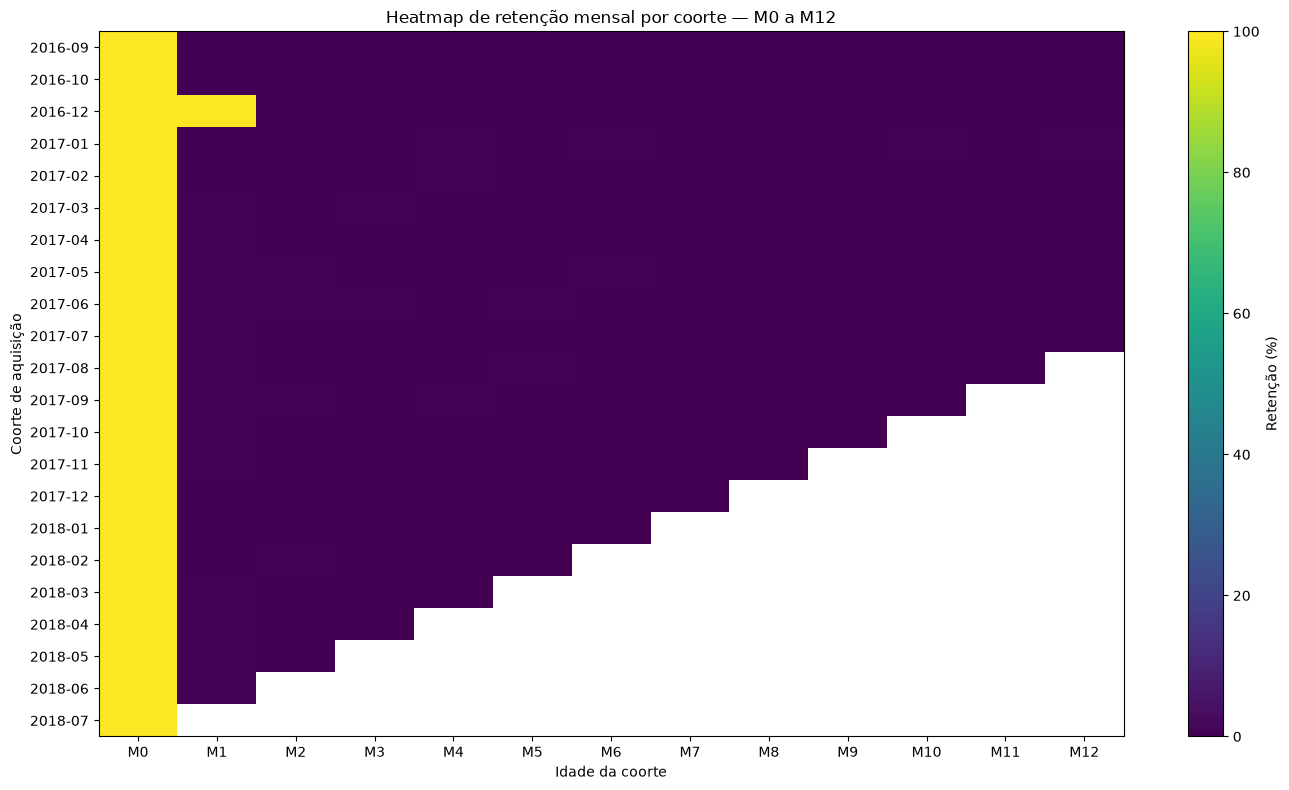

In [8]:
retention_plot = (
    customer_retention.iloc[:, :13]
    * 100
)

fig, ax = plt.subplots(figsize=(14, 8))

img = ax.imshow(
    retention_plot.values,
    aspect="auto",
)

fig.colorbar(
    img,
    ax=ax,
    label="Retenção (%)",
)

ax.set_title(
    "Heatmap de retenção mensal por coorte — M0 a M12"
)
ax.set_xlabel(
    "Idade da coorte"
)
ax.set_ylabel(
    "Coorte de aquisição"
)

ax.set_xticks(
    range(
        len(retention_plot.columns)
    ),
    retention_plot.columns,
)

ax.set_yticks(
    range(
        len(retention_plot.index)
    ),
    retention_plot.index,
)

plt.tight_layout()
plt.show()


## 6. Curva agregada de retenção — clientes elegíveis

Para cada idade da coorte, calculamos a retenção considerando apenas clientes de coortes maduras o suficiente para que aquele mês estivesse completamente observável.


In [9]:
customer_cohort = (
    first_purchase_month
    .reset_index()
)

customer_cohort[
    "cohort_age_complete_months"
] = (
    (
        last_complete_month.year
        - customer_cohort[
            "cohort_month"
        ].dt.year
    ) * 12
    +
    (
        last_complete_month.month
        - customer_cohort[
            "cohort_month"
        ].dt.month
    )
)

# Apenas clientes cuja coorte começou até o último mês completo
# podem compor curvas mensais comparáveis.
customer_cohort_complete = (
    customer_cohort.loc[
        customer_cohort[
            "cohort_month"
        ].le(last_complete_month)
    ]
    .copy()
)

activity = (
    customer_month_activity[
        [
            "customer_unique_id",
            "cohort_index",
        ]
    ]
    .drop_duplicates()
)

weighted_retention_rows = []

for month_index in range(
    0,
    min(max_age, 18) + 1
):
    eligible_ids = (
        customer_cohort_complete.loc[
            customer_cohort_complete[
                "cohort_age_complete_months"
            ].ge(month_index),
            "customer_unique_id",
        ]
        .drop_duplicates()
    )

    active_ids = set(
        activity.loc[
            activity[
                "cohort_index"
            ].eq(month_index),
            "customer_unique_id",
        ]
    )

    retained = (
        eligible_ids
        .isin(active_ids)
        .sum()
    )

    weighted_retention_rows.append({
        "cohort_index":
            month_index,
        "eligible_customers":
            int(len(eligible_ids)),
        "active_customers":
            int(retained),
        "retention_rate":
            retained / len(eligible_ids)
            if len(eligible_ids)
            else np.nan,
    })

weighted_retention = pd.DataFrame(
    weighted_retention_rows
)

display(
    weighted_retention.head(13)
)


,cohort_index,eligible_customers,active_customers,retention_rate
0,0,87214,87214,1.0000
1,1,81265,390,0.0048
2,2,75387,257,0.0034
3,3,68881,180,0.0026
4,4,62299,167,0.0027
5,5,55525,132,0.0024
6,6,49237,116,0.0024
7,7,42395,86,0.0020
8,8,37057,76,0.0021
9,9,29997,56,0.0019


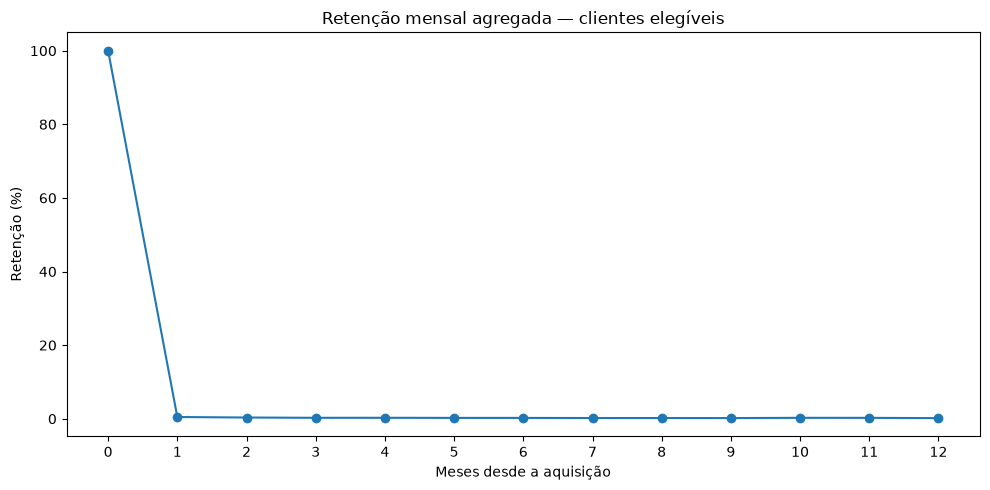

In [10]:
plot_wr = (
    weighted_retention.loc[
        weighted_retention[
            "cohort_index"
        ].le(12)
    ]
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_wr["cohort_index"],
    plot_wr["retention_rate"] * 100,
    marker="o",
)

ax.set_title(
    "Retenção mensal agregada — clientes elegíveis"
)
ax.set_xlabel(
    "Meses desde a aquisição"
)
ax.set_ylabel(
    "Retenção (%)"
)

ax.set_xticks(
    plot_wr["cohort_index"]
)

plt.tight_layout()
plt.show()


### Retenção mensal não é recompra acumulada

Um cliente pode:

- comprar em M1;
- não comprar em M2;
- voltar em M3.

Por isso:

- **retenção mensal** responde “comprou exatamente em Mk?”;
- **recompra acumulada** responde “já realizou uma segunda compra até Mk?”.


## 7. Recompra acumulada por idade da coorte

Para manter o mesmo denominador ao longo da curva acumulada, usamos apenas clientes com **12 meses completos de observação**.

Assim, M1, M3, M6 e M12 são comparados sobre a mesma população madura.


In [11]:
ordered = (
    delivered
    .sort_values(
        [
            "customer_unique_id",
            "order_purchase_timestamp",
            "order_id",
        ]
    )
    .copy()
)

ordered["order_number"] = (
    ordered
    .groupby(
        "customer_unique_id"
    )
    .cumcount()
    + 1
)

second_purchase = (
    ordered.loc[
        ordered[
            "order_number"
        ].eq(2),
        [
            "customer_unique_id",
            "order_month",
            "cohort_month",
        ],
    ]
    .copy()
)

second_purchase[
    "second_purchase_index"
] = (
    (
        second_purchase[
            "order_month"
        ].dt.year
        - second_purchase[
            "cohort_month"
        ].dt.year
    ) * 12
    +
    (
        second_purchase[
            "order_month"
        ].dt.month
        - second_purchase[
            "cohort_month"
        ].dt.month
    )
).astype(int)

customer_repeat_age = (
    customer_cohort
    .merge(
        second_purchase[
            [
                "customer_unique_id",
                "second_purchase_index",
            ]
        ],
        on="customer_unique_id",
        how="left",
        validate="one_to_one",
    )
)

FOLLOWUP_MONTHS = 12

mature_repeat_base = (
    customer_repeat_age.loc[
        customer_repeat_age[
            "cohort_age_complete_months"
        ].ge(FOLLOWUP_MONTHS)
    ]
    .copy()
)

cumulative_repeat_rows = []

for month_index in range(
    0,
    FOLLOWUP_MONTHS + 1
):
    repeated = (
        mature_repeat_base[
            "second_purchase_index"
        ].notna()
        & mature_repeat_base[
            "second_purchase_index"
        ].le(month_index)
    )

    cumulative_repeat_rows.append({
        "cohort_index":
            month_index,
        "eligible_customers":
            len(mature_repeat_base),
        "customers_with_second_purchase":
            int(repeated.sum()),
        "cumulative_repeat_rate":
            repeated.mean(),
    })

cumulative_repeat = pd.DataFrame(
    cumulative_repeat_rows
)

display(cumulative_repeat)


,cohort_index,eligible_customers,customers_with_second_purchase,cumulative_repeat_rate
0,0,17608,293,0.0166
1,1,17608,371,0.0211
2,2,17608,427,0.0243
3,3,17608,466,0.0265
4,4,17608,514,0.0292
5,5,17608,552,0.0313
6,6,17608,605,0.0344
7,7,17608,638,0.0362
8,8,17608,673,0.0382
9,9,17608,700,0.0398


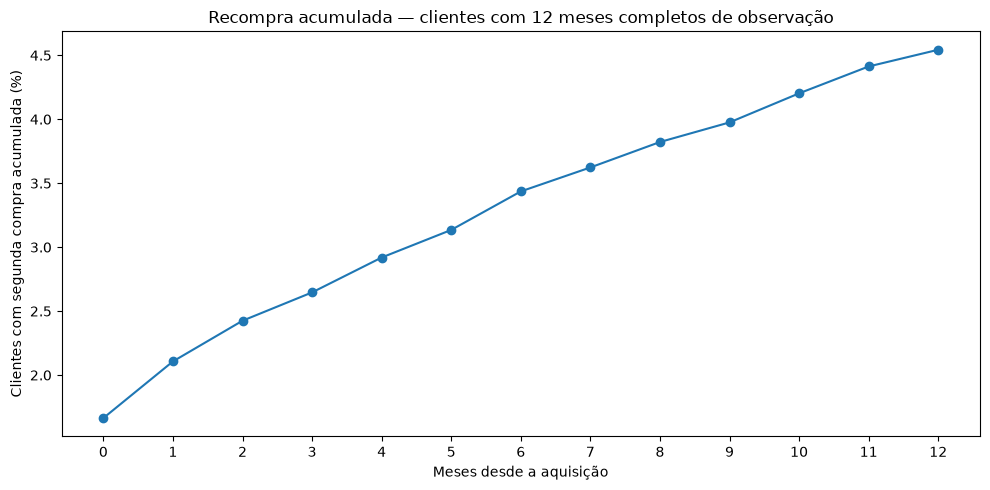

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    cumulative_repeat["cohort_index"],
    cumulative_repeat[
        "cumulative_repeat_rate"
    ] * 100,
    marker="o",
)

ax.set_title(
    "Recompra acumulada — clientes com 12 meses completos de observação"
)
ax.set_xlabel(
    "Meses desde a aquisição"
)
ax.set_ylabel(
    "Clientes com segunda compra acumulada (%)"
)

ax.set_xticks(
    cumulative_repeat[
        "cohort_index"
    ]
)

plt.tight_layout()
plt.show()


In [13]:
mature_population_kpis = pd.Series({
    "followup_months":
        FOLLOWUP_MONTHS,
    "mature_customers":
        len(mature_repeat_base),
    "mature_cohorts":
        mature_repeat_base[
            "cohort_month"
        ].nunique(),
})

mature_population_kpis


followup_months        12
mature_customers    17608
mature_cohorts         10
dtype: int64

## 8. Comparação de M1, M2, M3, M6 e M12 por safra

In [14]:
ret_long = (
    customer_retention
    .reset_index()
    .melt(
        id_vars="cohort_month",
        var_name="month_label",
        value_name="retention_rate",
    )
)

ret_long["cohort_index"] = (
    ret_long[
        "month_label"
    ]
    .str.replace(
        "M",
        "",
        regex=False,
    )
    .astype(int)
)

cohort_comparison = (
    cohort_sizes[
        [
            "cohort_month",
            "acquired_customers",
        ]
    ]
    .copy()
)

cohort_comparison[
    "cohort_month"
] = (
    cohort_comparison[
        "cohort_month"
    ].astype(str)
)

for k in [1, 2, 3, 6, 12]:
    temp = (
        ret_long.loc[
            ret_long[
                "cohort_index"
            ].eq(k),
            [
                "cohort_month",
                "retention_rate",
            ],
        ]
        .rename(
            columns={
                "retention_rate":
                    f"retention_M{k}"
            }
        )
    )

    cohort_comparison = (
        cohort_comparison
        .merge(
            temp,
            on="cohort_month",
            how="left",
        )
    )

display(cohort_comparison)


,cohort_month,acquired_customers,retention_M1,retention_M2,retention_M3,retention_M6,retention_M12
0,2016-09,1,0.0000,0.0000,0.0000,0.0000,0.0000
1,2016-10,262,0.0000,0.0000,0.0000,0.0038,0.0000
2,2016-12,1,1.0000,0.0000,0.0000,0.0000,0.0000
3,2017-01,717,0.0028,0.0028,0.0014,0.0042,0.0070
4,2017-02,1628,0.0018,0.0031,0.0012,0.0025,0.0012
5,2017-03,2503,0.0044,0.0036,0.0040,0.0016,0.0020
6,2017-04,2256,0.0062,0.0022,0.0018,0.0035,0.0004
7,2017-05,3451,0.0046,0.0046,0.0029,0.0041,0.0023
8,2017-06,3037,0.0049,0.0040,0.0043,0.0036,0.0016
9,2017-07,3752,0.0053,0.0035,0.0024,0.0032,0.0013


## 9. Benchmark de retenção por coorte

In [15]:
def weighted_retention_at(k):
    row = (
        weighted_retention.loc[
            weighted_retention[
                "cohort_index"
            ].eq(k)
        ]
    )

    return (
        row["retention_rate"].iloc[0]
        if len(row)
        else np.nan
    )

for k in [1, 3, 6]:
    benchmark = weighted_retention_at(k)

    cohort_comparison[
        f"delta_M{k}_vs_benchmark"
    ] = (
        cohort_comparison[
            f"retention_M{k}"
        ]
        - benchmark
    )

display(cohort_comparison)


,cohort_month,acquired_customers,retention_M1,retention_M2,retention_M3,retention_M6,retention_M12,delta_M1_vs_benchmark,delta_M3_vs_benchmark,delta_M6_vs_benchmark
0,2016-09,1,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0048,-0.0026,-0.0024
1,2016-10,262,0.0000,0.0000,0.0000,0.0038,0.0000,-0.0048,-0.0026,0.0015
2,2016-12,1,1.0000,0.0000,0.0000,0.0000,0.0000,0.9952,-0.0026,-0.0024
3,2017-01,717,0.0028,0.0028,0.0014,0.0042,0.0070,-0.0020,-0.0012,0.0018
4,2017-02,1628,0.0018,0.0031,0.0012,0.0025,0.0012,-0.0030,-0.0014,0.0001
5,2017-03,2503,0.0044,0.0036,0.0040,0.0016,0.0020,-0.0004,0.0014,-0.0008
6,2017-04,2256,0.0062,0.0022,0.0018,0.0035,0.0004,0.0014,-0.0008,0.0012
7,2017-05,3451,0.0046,0.0046,0.0029,0.0041,0.0023,-0.0002,0.0003,0.0017
8,2017-06,3037,0.0049,0.0040,0.0043,0.0036,0.0016,0.0001,0.0017,0.0013
9,2017-07,3752,0.0053,0.0035,0.0024,0.0032,0.0013,0.0005,-0.0002,0.0008


### Uso executivo

O benchmark ajuda a responder:

> “Esta coorte performou melhor ou pior do que a média das coortes elegíveis na mesma idade?”

Isso é mais informativo do que comparar taxas isoladas.


## 10. Revenue Index por coorte

O **Revenue Index** compara a receita mensal da coorte com a receita gerada no mês de aquisição:

\[
\text{Revenue Index}_{M_k}
=
\frac{
\text{Receita da coorte em } M_k
}{
\text{Receita da coorte em } M_0
}
\]

O indicador:

- não mede percentual de clientes retidos;
- não é SaaS NRR;
- pode superar 100% se a coorte gerar mais receita em um mês posterior do que em M0.


In [16]:
cohort_revenue = (
    delivered_financial
    .groupby(
        [
            "cohort_month",
            "cohort_index",
        ]
    )["payment_value"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
    .reindex(
        columns=range(max_age + 1),
        fill_value=0,
    )
)

m0_revenue = cohort_revenue[0].replace(
    0,
    np.nan,
)

revenue_retention = (
    cohort_revenue
    .div(
        m0_revenue,
        axis=0,
    )
)

for cm in revenue_retention.index:
    observed_age = (
        (last_complete_month.year - cm.year) * 12
        + (last_complete_month.month - cm.month)
    )

    revenue_retention.loc[
        cm,
        revenue_retention.columns > observed_age
    ] = np.nan

revenue_retention.index = (
    revenue_retention.index.astype(str)
)

revenue_retention.index.name = (
    "cohort_month"
)

revenue_retention.columns = [
    f"M{i}"
    for i in revenue_retention.columns
]

display(
    (
        revenue_retention.iloc[:, :13]
        * 100
    ).round(2)
)


,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
cohort_month,,,,,,,,,,,,,
2016-10,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2400,0.0000,0.0000,0.7600,0.0000,0.1200,0.0000
2016-12,100.0000,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2017-01,100.0000,0.0900,0.0900,0.0700,0.1900,0.0500,0.3500,0.0800,0.0400,0.0000,0.3300,0.0500,0.4300
2017-02,100.0000,0.1800,0.2100,0.0400,0.4200,0.0300,0.2500,0.1000,0.1700,0.1400,0.1300,0.1700,0.1000
2017-03,100.0000,0.3900,0.4200,0.4400,0.2900,0.3500,0.1700,0.2100,0.3300,0.0600,0.1800,0.0900,0.2200
2017-04,100.0000,0.7600,0.2400,0.2000,0.3000,0.3100,0.5400,0.2800,0.2500,0.1300,0.1800,0.0900,0.0500
2017-05,100.0000,0.3400,0.5100,0.3300,0.2200,0.2900,0.5300,0.1100,0.2900,0.2400,0.2600,0.2600,0.1900
2017-06,100.0000,0.4500,0.4400,0.3100,0.3000,0.3300,0.3300,0.1700,0.0700,0.1000,0.4600,0.4300,0.1100
2017-07,100.0000,0.5500,0.2300,0.2100,0.2300,0.3300,0.4600,0.0400,0.0700,0.3700,0.2100,0.2300,0.2500


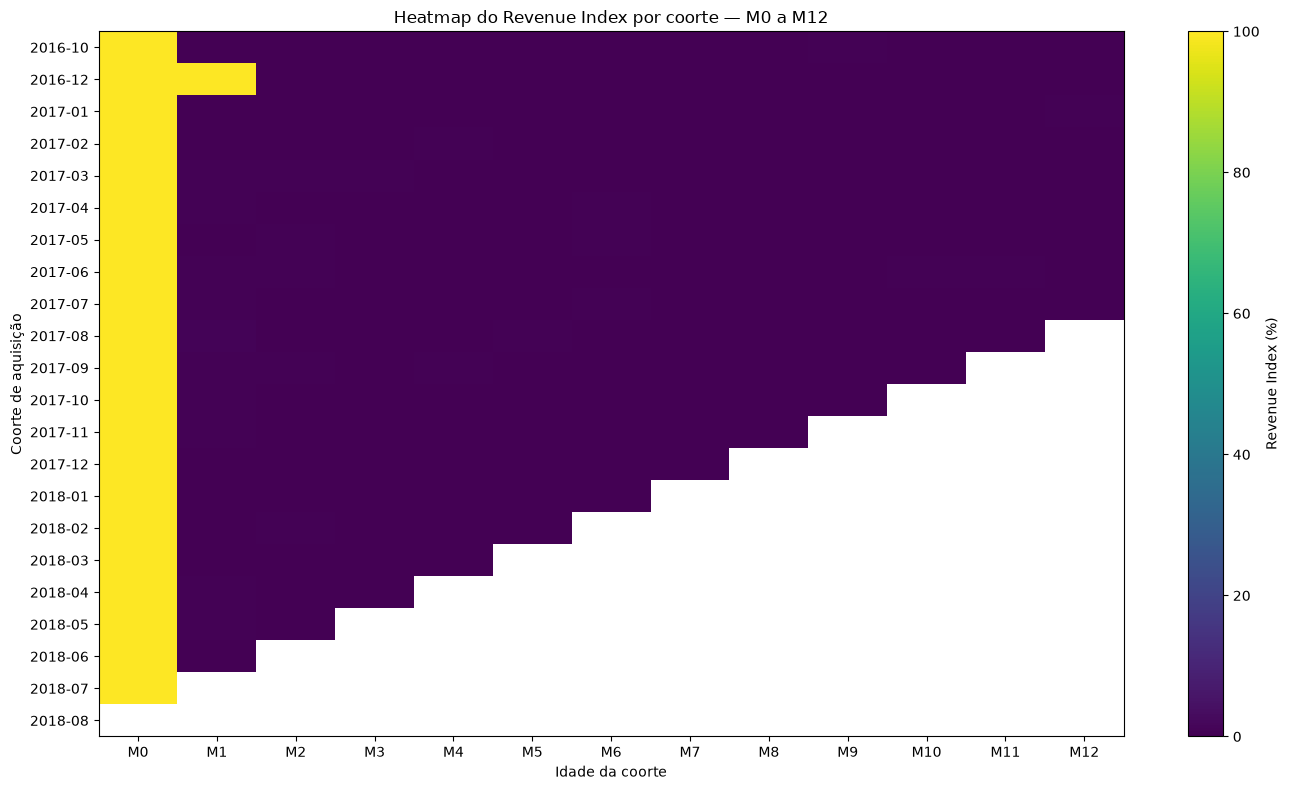

In [17]:
revenue_plot = (
    revenue_retention.iloc[:, :13]
    * 100
)

fig, ax = plt.subplots(figsize=(14, 8))

img = ax.imshow(
    revenue_plot.values,
    aspect="auto",
)

fig.colorbar(
    img,
    ax=ax,
    label="Revenue Index (%)",
)

ax.set_title(
    "Heatmap do Revenue Index por coorte — M0 a M12"
)
ax.set_xlabel(
    "Idade da coorte"
)
ax.set_ylabel(
    "Coorte de aquisição"
)

ax.set_xticks(
    range(
        len(revenue_plot.columns)
    ),
    revenue_plot.columns,
)

ax.set_yticks(
    range(
        len(revenue_plot.index)
    ),
    revenue_plot.index,
)

plt.tight_layout()
plt.show()


## 11. Receita acumulada por cliente adquirido — proxy de LTV observado

A receita acumulada por cliente adquirido é uma **proxy descritiva de LTV observado**.

Ela não representa CLV predito porque o dataset não contém:

- margem;
- CAC;
- horizonte futuro;
- taxa de desconto;
- custo promocional.


In [18]:
cohort_revenue_raw = (
    delivered_financial
    .groupby(
        [
            "cohort_month",
            "cohort_index",
        ]
    )["payment_value"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
    .reindex(
        columns=range(max_age + 1),
        fill_value=0,
    )
)

cohort_sizes_period = (
    first_purchase_month
    .value_counts()
    .sort_index()
)

cumulative_revenue_per_customer = (
    cohort_revenue_raw
    .cumsum(axis=1)
    .div(
        cohort_sizes_period,
        axis=0,
    )
)

for cm in cumulative_revenue_per_customer.index:
    observed_age = (
        (last_complete_month.year - cm.year) * 12
        + (last_complete_month.month - cm.month)
    )

    cumulative_revenue_per_customer.loc[
        cm,
        cumulative_revenue_per_customer.columns > observed_age
    ] = np.nan

cumulative_revenue_per_customer.index = (
    cumulative_revenue_per_customer.index.astype(str)
)

cumulative_revenue_per_customer.index.name = (
    "cohort_month"
)

cumulative_revenue_per_customer.columns = [
    f"M{i}"
    for i in cumulative_revenue_per_customer.columns
]

display(
    cumulative_revenue_per_customer.iloc[:, :13]
    .round(2)
)


,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
cohort_month,,,,,,,,,,,,,
2016-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,177.7400,177.7400,177.7400,177.7400,177.7400,177.7400,178.1600,178.1600,178.1600,179.5200,179.5200,179.7400,179.7400
2016-12,19.6200,39.2400,39.2400,39.2400,39.2400,39.2400,39.2400,39.2400,39.2400,39.2400,39.2400,39.2400,39.2400
2017-01,177.8600,178.0200,178.1800,178.3000,178.6400,178.7400,179.3700,179.5100,179.5800,179.5800,180.1700,180.2700,181.0400
2017-02,166.5800,166.8700,167.2200,167.3000,168.0000,168.0500,168.4700,168.6400,168.9300,169.1600,169.3700,169.6500,169.8200
2017-03,165.3100,165.9600,166.6500,167.3900,167.8700,168.4400,168.7200,169.0700,169.6300,169.7200,170.0100,170.1700,170.5300
2017-04,172.2300,173.5300,173.9500,174.2900,174.8000,175.3400,176.2600,176.7500,177.1700,177.4000,177.7000,177.8600,177.9300
2017-05,162.8600,163.4200,164.2500,164.7800,165.1300,165.6100,166.4800,166.6500,167.1200,167.5200,167.9400,168.3600,168.6600
2017-06,159.4700,160.1800,160.8800,161.3700,161.8400,162.3700,162.9000,163.1700,163.2800,163.4500,164.1800,164.8600,165.0300


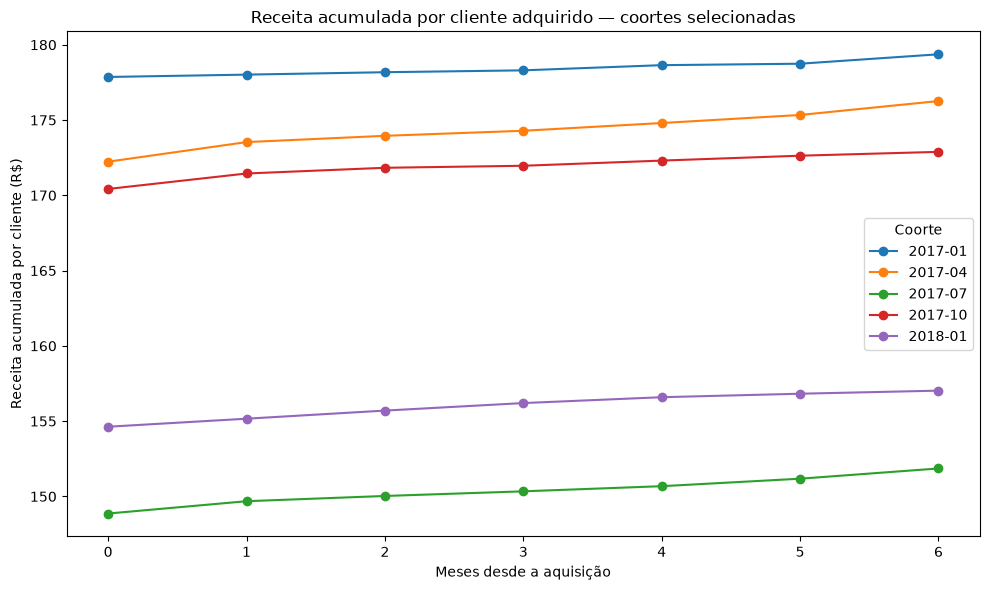

In [19]:
MIN_COHORT_SIZE = 300

eligible_curves = (
    cohort_comparison.loc[
        cohort_comparison[
            "acquired_customers"
        ].ge(MIN_COHORT_SIZE)
        & cohort_comparison[
            "retention_M6"
        ].notna(),
        "cohort_month",
    ]
    .tolist()
)

if len(eligible_curves) > 5:
    idx = (
        np.linspace(
            0,
            len(eligible_curves) - 1,
            5,
        )
        .round()
        .astype(int)
    )

    selected_cohorts = [
        eligible_curves[i]
        for i in idx
    ]
else:
    selected_cohorts = eligible_curves

fig, ax = plt.subplots(figsize=(10, 6))

for cohort in selected_cohorts:
    row = (
        cumulative_revenue_per_customer.loc[
            cohort,
            [
                f"M{i}"
                for i in range(0, 7)
            ],
        ]
    )

    ax.plot(
        range(0, 7),
        row.values,
        marker="o",
        label=cohort,
    )

ax.set_title(
    "Receita acumulada por cliente adquirido — coortes selecionadas"
)
ax.set_xlabel(
    "Meses desde a aquisição"
)
ax.set_ylabel(
    "Receita acumulada por cliente (R$)"
)

ax.set_xticks(
    range(0, 7)
)

if selected_cohorts:
    ax.legend(
        title="Coorte"
    )

plt.tight_layout()
plt.show()


## 12. Meio principal da primeira compra × retenção

In [20]:
required_payment_cols = {
    "order_id",
    "primary_payment_type",
}

missing_payment_cols = (
    required_payment_cols
    .difference(
        payment_behavior.columns
    )
)

if missing_payment_cols:
    raise ValueError(
        "Colunas ausentes em payment_behavior_order_level.csv: "
        f"{sorted(missing_payment_cols)}"
    )

first_orders = (
    ordered.loc[
        ordered[
            "order_number"
        ].eq(1),
        [
            "customer_unique_id",
            "order_id",
            "cohort_month",
        ],
    ]
    .rename(
        columns={
            "order_id": "first_order_id"
        }
    )
)

customer_acquisition = (
    customer_cohort
    .merge(
        first_orders[
            [
                "customer_unique_id",
                "first_order_id",
            ]
        ],
        on="customer_unique_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        payment_behavior[
            [
                "order_id",
                "primary_payment_type",
            ]
        ].rename(
            columns={
                "order_id":
                    "first_order_id"
            }
        ),
        on="first_order_id",
        how="left",
        validate="one_to_one",
    )
)

customer_acquisition[
    "primary_payment_type"
] = (
    customer_acquisition[
        "primary_payment_type"
    ]
    .fillna("unknown")
)

display(
    customer_acquisition[
        "primary_payment_type"
    ]
    .value_counts(
        dropna=False
    )
    .to_frame(
        "customers"
    )
)


,customers
primary_payment_type,
credit_card,70420
boleto,18625
voucher,2872
debit_card,1440
unknown,1


In [21]:
retention_payment_rows = []

for payment_type, group in (
    customer_acquisition
    .groupby(
        "primary_payment_type"
    )
):
    for month_index in range(1, 7):
        eligible = (
            group.loc[
                group[
                    "cohort_age_complete_months"
                ].ge(month_index),
                "customer_unique_id",
            ]
        )

        active_ids = set(
            activity.loc[
                activity[
                    "cohort_index"
                ].eq(month_index),
                "customer_unique_id",
            ]
        )

        retained = (
            eligible
            .isin(active_ids)
            .sum()
        )

        retention_payment_rows.append({
            "primary_payment_type":
                payment_type,
            "cohort_index":
                month_index,
            "eligible_customers":
                len(eligible),
            "active_customers":
                int(retained),
            "retention_rate":
                retained / len(eligible)
                if len(eligible)
                else np.nan,
        })

retention_by_payment = pd.DataFrame(
    retention_payment_rows
)

display(retention_by_payment)


,primary_payment_type,cohort_index,eligible_customers,active_customers,retention_rate
0,boleto,1,16372,80,0.0049
1,boleto,2,15311,60,0.0039
2,boleto,3,14114,26,0.0018
3,boleto,4,12884,40,0.0031
4,boleto,5,11604,27,0.0023
5,boleto,6,10357,26,0.0025
6,credit_card,1,61367,291,0.0047
7,credit_card,2,56902,186,0.0033
8,credit_card,3,51792,140,0.0027
9,credit_card,4,46720,125,0.0027


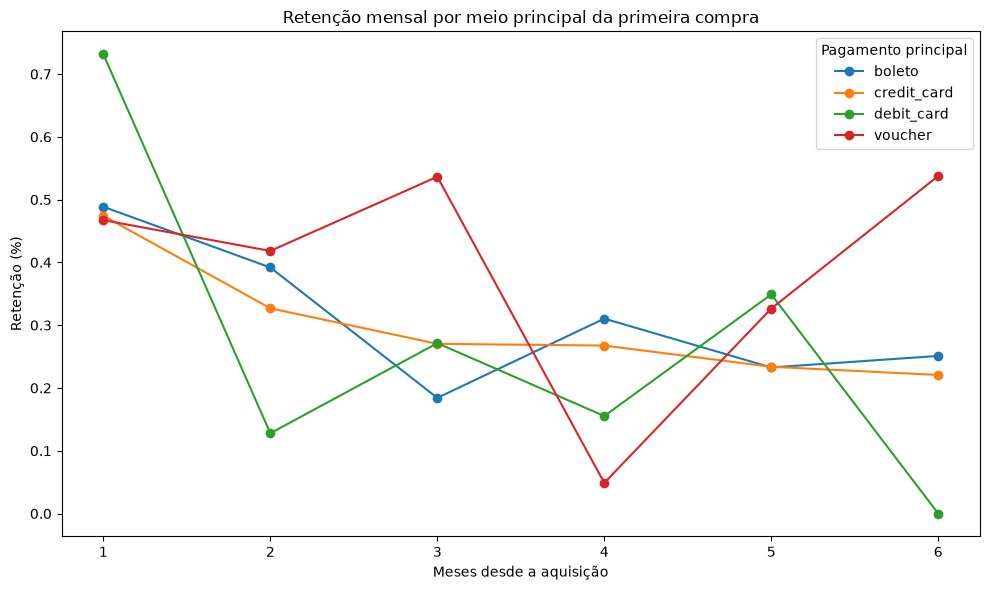

In [22]:
MIN_PAYMENT_CUSTOMERS = 500

payment_sizes = (
    customer_acquisition[
        "primary_payment_type"
    ]
    .value_counts()
)

major_payment_types = (
    payment_sizes.loc[
        payment_sizes.ge(
            MIN_PAYMENT_CUSTOMERS
        )
    ]
    .index
    .tolist()
)

plot_pay = (
    retention_by_payment.loc[
        retention_by_payment[
            "primary_payment_type"
        ].isin(
            major_payment_types
        )
        & retention_by_payment[
            "primary_payment_type"
        ].ne("unknown")
    ]
)

fig, ax = plt.subplots(figsize=(10, 6))

for payment_type, group in (
    plot_pay
    .groupby(
        "primary_payment_type"
    )
):
    ax.plot(
        group["cohort_index"],
        group["retention_rate"] * 100,
        marker="o",
        label=payment_type,
    )

ax.set_title(
    "Retenção mensal por meio principal da primeira compra"
)
ax.set_xlabel(
    "Meses desde a aquisição"
)
ax.set_ylabel(
    "Retenção (%)"
)

ax.set_xticks(
    range(1, 7)
)

if not plot_pay.empty:
    ax.legend(
        title="Pagamento principal"
    )

plt.tight_layout()
plt.show()


## 13. Resumo executivo por coorte

In [23]:
acquisition_revenue = (
    delivered_financial.loc[
        delivered_financial[
            "cohort_index"
        ].eq(0)
    ]
    .groupby(
        "cohort_month"
    )["payment_value"]
    .sum()
    .rename(
        "acquisition_month_revenue"
    )
    .reset_index()
)

cohort_summary = (
    cohort_sizes[
        [
            "cohort_month",
            "acquired_customers",
        ]
    ]
    .copy()
    .merge(
        acquisition_revenue,
        on="cohort_month",
        how="left",
    )
)

cohort_summary[
    "avg_acquisition_month_revenue_per_customer"
] = (
    cohort_summary[
        "acquisition_month_revenue"
    ]
    / cohort_summary[
        "acquired_customers"
    ]
)

cohort_summary[
    "cohort_month"
] = (
    cohort_summary[
        "cohort_month"
    ].astype(str)
)

for k in [1, 2, 3, 6, 12]:
    temp = (
        ret_long.loc[
            ret_long[
                "cohort_index"
            ].eq(k),
            [
                "cohort_month",
                "retention_rate",
            ],
        ]
        .rename(
            columns={
                "retention_rate":
                    f"retention_M{k}"
            }
        )
    )

    cohort_summary = (
        cohort_summary
        .merge(
            temp,
            on="cohort_month",
            how="left",
        )
    )

for k in [1, 3, 6]:
    benchmark = weighted_retention_at(k)

    cohort_summary[
        f"delta_M{k}_vs_benchmark"
    ] = (
        cohort_summary[
            f"retention_M{k}"
        ]
        - benchmark
    )

for k in [3, 6, 12]:
    col = f"M{k}"

    if col in cumulative_revenue_per_customer.columns:
        temp = (
            cumulative_revenue_per_customer[
                [col]
            ]
            .reset_index()
            .rename(
                columns={
                    col:
                        f"cum_revenue_per_customer_M{k}"
                }
            )
        )

        cohort_summary = (
            cohort_summary
            .merge(
                temp,
                on="cohort_month",
                how="left",
            )
        )

display(cohort_summary)


,cohort_month,acquired_customers,acquisition_month_revenue,avg_acquisition_month_revenue_per_customer,retention_M1,retention_M2,retention_M3,retention_M6,retention_M12,delta_M1_vs_benchmark,delta_M3_vs_benchmark,delta_M6_vs_benchmark,cum_revenue_per_customer_M3,cum_revenue_per_customer_M6,cum_revenue_per_customer_M12
0,2016-09,1,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0048,-0.0026,-0.0024,NaN,NaN,NaN
1,2016-10,262,"46,566.7100",177.7355,0.0000,0.0000,0.0000,0.0038,0.0000,-0.0048,-0.0026,0.0015,177.7355,178.1603,179.7363
2,2016-12,1,19.6200,19.6200,1.0000,0.0000,0.0000,0.0000,0.0000,0.9952,-0.0026,-0.0024,39.2400,39.2400,39.2400
3,2017-01,717,"127,526.0500",177.8606,0.0028,0.0028,0.0014,0.0042,0.0070,-0.0020,-0.0012,0.0018,178.3006,179.3662,181.0374
4,2017-02,1628,"271,187.5800",166.5771,0.0018,0.0031,0.0012,0.0025,0.0012,-0.0030,-0.0014,0.0001,167.2964,168.4728,169.8248
5,2017-03,2503,"413,773.0100",165.3108,0.0044,0.0036,0.0040,0.0016,0.0020,-0.0004,0.0014,-0.0008,167.3871,168.7201,170.5277
6,2017-04,2256,"388,556.9200",172.2327,0.0062,0.0022,0.0018,0.0035,0.0004,0.0014,-0.0008,0.0012,174.2875,176.2602,177.9328
7,2017-05,3451,"562,027.6300",162.8594,0.0046,0.0046,0.0029,0.0041,0.0023,-0.0002,0.0003,0.0017,164.7790,166.4770,168.6618
8,2017-06,3037,"484,296.2400",159.4653,0.0049,0.0040,0.0043,0.0036,0.0016,0.0001,0.0017,0.0013,161.3715,162.8964,165.0285
9,2017-07,3752,"558,533.4300",148.8629,0.0053,0.0035,0.0024,0.0032,0.0013,0.0005,-0.0002,0.0008,150.3379,151.8572,153.6089


## 14. KPIs executivos

In [24]:
def cumulative_repeat_at(k):
    row = (
        cumulative_repeat.loc[
            cumulative_repeat[
                "cohort_index"
            ].eq(k)
        ]
    )

    return (
        row[
            "cumulative_repeat_rate"
        ].iloc[0]
        if len(row)
        else np.nan
    )

def eligible_customers_at(k):
    row = (
        weighted_retention.loc[
            weighted_retention[
                "cohort_index"
            ].eq(k)
        ]
    )

    return (
        int(
            row[
                "eligible_customers"
            ].iloc[0]
        )
        if len(row)
        else 0
    )

repeat_customers = int(
    second_purchase[
        "customer_unique_id"
    ].nunique()
)

raw_repeat_rate = (
    repeat_customers
    / delivered[
        "customer_unique_id"
    ].nunique()
)

executive_kpis = pd.DataFrame({
    "kpi": [
        "customers_delivered",
        "cohorts_observed",
        "raw_repeat_rate_any_time",
        "retention_M1_weighted",
        "eligible_customers_M1",
        "retention_M3_weighted",
        "eligible_customers_M3",
        "retention_M6_weighted",
        "eligible_customers_M6",
        "retention_M12_weighted",
        "eligible_customers_M12",
        "cumulative_repeat_by_M1",
        "cumulative_repeat_by_M3",
        "cumulative_repeat_by_M6",
        "cumulative_repeat_by_M12",
        "mature_customers_12m",
    ],
    "value": [
        delivered[
            "customer_unique_id"
        ].nunique(),
        cohort_sizes[
            "cohort_month"
        ].nunique(),
        raw_repeat_rate,
        weighted_retention_at(1),
        eligible_customers_at(1),
        weighted_retention_at(3),
        eligible_customers_at(3),
        weighted_retention_at(6),
        eligible_customers_at(6),
        weighted_retention_at(12),
        eligible_customers_at(12),
        cumulative_repeat_at(1),
        cumulative_repeat_at(3),
        cumulative_repeat_at(6),
        cumulative_repeat_at(12),
        len(mature_repeat_base),
    ],
})

display(executive_kpis)


,kpi,value
0,customers_delivered,"93,358.0000"
1,cohorts_observed,23.0000
2,raw_repeat_rate_any_time,0.0300
3,retention_M1_weighted,0.0048
4,eligible_customers_M1,"81,265.0000"
5,retention_M3_weighted,0.0026
6,eligible_customers_M3,"68,881.0000"
7,retention_M6_weighted,0.0024
8,eligible_customers_M6,"49,237.0000"
9,retention_M12_weighted,0.0018


## 15. Metadata temporal

In [25]:
cohort_metadata = pd.DataFrame({
    "metric": [
        "dataset_start",
        "dataset_end",
        "last_observed_month",
        "last_complete_month",
        "followup_months_cumulative_repeat",
    ],
    "value": [
        str(dataset_start),
        str(dataset_end),
        str(last_observed_month),
        str(last_complete_month),
        str(FOLLOWUP_MONTHS),
    ],
})

cohort_metadata


,metric,value
0,dataset_start,2016-09-15 12:16:38
1,dataset_end,2018-08-29 15:00:37
2,last_observed_month,2018-08
3,last_complete_month,2018-07
4,followup_months_cumulative_repeat,12


## 16. Leitura executiva

In [26]:
print("LEITURA EXECUTIVA")
print("-" * 90)

print(
    f"1. A base entregue reúne "
    f"{delivered['customer_unique_id'].nunique():,} clientes "
    f"em {cohort_sizes['cohort_month'].nunique()} coortes mensais."
)

print(
    f"2. A retenção ponderada é "
    f"{weighted_retention_at(1):.2%} em M1, "
    f"{weighted_retention_at(3):.2%} em M3 e "
    f"{weighted_retention_at(6):.2%} em M6."
)

print(
    f"3. Entre clientes com 12 meses completos de observação, "
    f"a recompra acumulada chega a "
    f"{cumulative_repeat_at(1):.2%} até M1, "
    f"{cumulative_repeat_at(3):.2%} até M3 e "
    f"{cumulative_repeat_at(6):.2%} até M6."
)

print(
    f"4. A taxa observada de clientes com pelo menos dois "
    f"pedidos entregues é {raw_repeat_rate:.2%}."
)

print(
    "5. Retenção mensal e recompra acumulada respondem "
    "perguntas diferentes e devem aparecer separadamente."
)

print(
    f"6. O último mês completo utilizado para maturidade "
    f"das coortes é {last_complete_month}."
)

print(
    "7. Receita acumulada por cliente ajuda a avaliar "
    "a qualidade econômica das safras sem confundir "
    "frequência mensal com valor gerado."
)


LEITURA EXECUTIVA
------------------------------------------------------------------------------------------
1. A base entregue reúne 93,358 clientes em 23 coortes mensais.
2. A retenção ponderada é 0.48% em M1, 0.26% em M3 e 0.24% em M6.
3. Entre clientes com 12 meses completos de observação, a recompra acumulada chega a 2.11% até M1, 2.65% até M3 e 3.44% até M6.
4. A taxa observada de clientes com pelo menos dois pedidos entregues é 3.00%.
5. Retenção mensal e recompra acumulada respondem perguntas diferentes e devem aparecer separadamente.
6. O último mês completo utilizado para maturidade das coortes é 2018-07.
7. Receita acumulada por cliente ajuda a avaliar a qualidade econômica das safras sem confundir frequência mensal com valor gerado.


## 17. Recomendações para storytelling executivo

### Tese 1 — Aquisição e relacionamento devem ser lidos separadamente

O volume de novos clientes não deve ser interpretado como melhora automática da retenção.

### Tese 2 — A maturidade das coortes precisa ser respeitada

Coortes recentes só devem ser comparadas em idades já completamente observáveis.

### Tese 3 — Retenção mensal e recompra acumulada são complementares

A primeira mostra atividade em um mês específico; a segunda mostra conversão acumulada à segunda compra.

### Tese 4 — Valor econômico deve acompanhar retenção

O Revenue Index e a receita acumulada por cliente adquirido ajudam a distinguir coortes com baixa frequência mensal, mas valor relevante.

### Tese 5 — Pagamento é sinal de segmentação, não causa

Diferenças de retenção por meio principal podem refletir categoria, ticket e perfil do cliente.

### Ação sugerida

Acompanhar cada nova safra por:

- M1;
- M3;
- M6;
- recompra acumulada;
- receita acumulada por cliente;
- delta versus benchmark.

Esse scorecard é mais informativo do que olhar apenas pedidos ou GMV total.


## 18. Sanity checks

In [27]:
assert delivered[
    "cohort_index"
].ge(0).all(), (
    "Há cohort_index negativo."
)

assert (
    last_complete_month
    <= last_observed_month
)

# M0 deve ser exatamente 100% para todas as coortes completas.
assert np.allclose(
    customer_retention[
        "M0"
    ].dropna(),
    1.0,
), "M0 da retenção deve ser 100%."

# Validar somente células efetivamente observadas.
# NaNs são esperados para meses futuros / ainda não observáveis.
retention_values = (
    customer_retention
    .drop(
        columns=["M0"]
    )
    .stack()
    .dropna()
)

invalid_retention = (
    retention_values.loc[
        ~retention_values.between(0, 1)
    ]
)

if not invalid_retention.empty:
    print(
        "Valores realmente inválidos encontrados na matriz de retenção:"
    )
    display(
        invalid_retention
        .rename("retention_rate")
        .reset_index()
    )

assert invalid_retention.empty, (
    "Há taxas observadas de retenção fora de [0,1]."
)

# Confirmar que NaNs existem apenas como ausência esperada de observação
# e não afetam as células observadas.
observed_retention = (
    customer_retention
    .drop(
        columns=["M0"]
    )
)

observed_numeric = (
    observed_retention
    .stack()
    .dropna()
)

assert observed_numeric.between(
    0, 1
).all()

assert (
    weighted_retention[
        "retention_rate"
    ]
    .dropna()
    .between(0, 1)
    .all()
)

assert (
    weighted_retention[
        "active_customers"
    ]
    .le(
        weighted_retention[
            "eligible_customers"
        ]
    )
    .all()
)

assert (
    cumulative_repeat[
        "cumulative_repeat_rate"
    ]
    .between(0, 1)
    .all()
)

assert (
    cumulative_repeat[
        "cumulative_repeat_rate"
    ]
    .is_monotonic_increasing
), (
    "Com denominador fixo, a recompra acumulada "
    "deve ser não decrescente."
)

assert (
    second_purchase[
        "second_purchase_index"
    ]
    .ge(0)
    .all()
)

assert customer_acquisition[
    "customer_unique_id"
].is_unique

assert cohort_summary[
    "cohort_month"
].is_unique

assert (
    cohort_sizes[
        "acquired_customers"
    ].sum()
    == delivered[
        "customer_unique_id"
    ].nunique()
)

assert delivered_financial[
    "payment_value"
].ge(0).all()

numeric_cum = (
    cumulative_revenue_per_customer
    .select_dtypes(
        include="number"
    )
    .to_numpy()
)

assert not np.isinf(
    numeric_cum
).any()

print(
    "Sanity checks concluídos com sucesso."
)


Sanity checks concluídos com sucesso.


## 19. Exportação das camadas analíticas

In [28]:
customer_retention_export = (
    customer_retention
    .reset_index()
)

revenue_retention_export = (
    revenue_retention
    .reset_index()
)

cumulative_revenue_export = (
    cumulative_revenue_per_customer
    .reset_index()
)

exports = {
    "cohort_customer_retention_matrix.csv":
        customer_retention_export,
    "cohort_weighted_retention_curve.csv":
        weighted_retention,
    "cohort_cumulative_repeat_curve.csv":
        cumulative_repeat,
    "cohort_revenue_index_matrix.csv":
        revenue_retention_export,
    "cohort_cumulative_revenue_per_customer.csv":
        cumulative_revenue_export,
    "cohort_retention_by_first_payment.csv":
        retention_by_payment,
    "cohort_summary.csv":
        cohort_summary,
    "cohort_executive_kpis.csv":
        executive_kpis,
    "cohort_metadata.csv":
        cohort_metadata,
    "cohort_benchmark_comparison.csv":
        cohort_comparison,
}

for filename, df in exports.items():
    path = (
        PROCESSED_DIR
        / filename
    )

    df.to_csv(
        path,
        index=False,
    )

    print(
        "Exportado:",
        path,
        df.shape,
    )


Exportado: c:\Users\F6363856\OneDrive - Banco do Brasil S.A\Área de Trabalho\Pós Data Analytics\1 entregavel\entregavel\data\processed\cohort_customer_retention_matrix.csv (22, 24)
Exportado: c:\Users\F6363856\OneDrive - Banco do Brasil S.A\Área de Trabalho\Pós Data Analytics\1 entregavel\entregavel\data\processed\cohort_weighted_retention_curve.csv (19, 4)
Exportado: c:\Users\F6363856\OneDrive - Banco do Brasil S.A\Área de Trabalho\Pós Data Analytics\1 entregavel\entregavel\data\processed\cohort_cumulative_repeat_curve.csv (13, 4)
Exportado: c:\Users\F6363856\OneDrive - Banco do Brasil S.A\Área de Trabalho\Pós Data Analytics\1 entregavel\entregavel\data\processed\cohort_revenue_index_matrix.csv (22, 24)
Exportado: c:\Users\F6363856\OneDrive - Banco do Brasil S.A\Área de Trabalho\Pós Data Analytics\1 entregavel\entregavel\data\processed\cohort_cumulative_revenue_per_customer.csv (23, 24)
Exportado: c:\Users\F6363856\OneDrive - Banco do Brasil S.A\Área de Trabalho\Pós Data Analytics\1 e

## Conclusão

O Notebook 05 transforma a base de pedidos em uma visão longitudinal de aquisição, retenção e valor por safra.

As principais saídas são:

1. **Heatmap de retenção mensal** com maturidade baseada no último mês completo;
2. **Curva de recompra acumulada** com denominador fixo para coortes maduras;
3. **Revenue Index** por coorte;
4. **Receita acumulada por cliente adquirido** como proxy descritiva de LTV observado;
5. **Retenção por meio principal de pagamento**;
6. **Scorecard por coorte** com benchmark e deltas;
7. **KPIs com denominadores explícitos** para uso em Power BI.

O próximo passo é o **Notebook 06 — Repurchase Prediction**, usando a base preparada no Notebook 04 para estimar a probabilidade de recompra em 90 dias com validação temporal.
